# Forecasting each merchant's next 12 months

The BNPL firm onboards merchants for the future, so the ranking should use what each merchant is **expected to
earn the firm next year**, not just what it did in the past. This notebook forecasts two things for every merchant
for the 12 months after the data ends (27 Oct 2022 to 26 Oct 2023):

1. **Sales**, and from them BNPL revenue (`take_rate` x sales).
2. **Fraud rate**: the share of those sales expected to be fraudulent.

`features.ipynb` found that every merchant follows the same seasonal pattern and grows at about the same rate.
This suggests a simple forecast could work as well as a complex one, so several candidate methods are tested
on data they haven't seen before one is chosen.

This notebook only needs the merchant-day totals from `features.ipynb`, so it runs in pandas without Spark.

Output: `curated/merchant_forecast.parquet`, one row per merchant.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter
from scipy.stats import spearmanr

Settings and helper functions used throughout this notebook: file paths, key dates, chart colours and formatting.

In [2]:
# Files
CURATED = Path("curated")              # files the notebooks pass to each other
PLOTS = Path("plots")                  # charts, saved for the presentation
MERCHANT_DAILY = CURATED / "merchant_daily.parquet"          # from features.ipynb
MERCHANT_FEATURES = CURATED / "merchant_features.parquet"    # from features.ipynb
MERCHANT_FORECAST = CURATED / "merchant_forecast.parquet"    # from forecast.ipynb

# Key dates
LAST_DAY = "2022-10-26"         # last day of the transactions
SECOND_SNAPSHOT = "2021-08-28"  # first day of the second snapshot: the fraud files flag ~6x more from here
COVERAGE_END = "2022-02-27"     # last day either fraud file covers
LAST_12M_START = "2021-10-27"   # the last 12 months of data: 27 Oct 2021 - 26 Oct 2022

# Chart colours
SURFACE, INK, INK_SECONDARY, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE = "#2a78d6"            # the main colour


def apply_style():
    """Quiet, consistent chart defaults (the same palette as etl.ipynb). Also stops Jupyter reading the dollar
    signs in tables as maths formulas."""
    pd.set_option("display.html.use_mathjax", False)
    pd.set_option("styler.html.mathjax", False)
    plt.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
        "axes.edgecolor": GRID, "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK,
        "axes.titlesize": 11, "axes.titlelocation": "left", "axes.labelsize": 10,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1, "axes.axisbelow": True,
        "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_SECONDARY, "ytick.labelcolor": INK_SECONDARY,
        "legend.frameon": False, "legend.labelcolor": INK, "font.size": 10,
        "lines.linewidth": 2, "lines.solid_capstyle": "round",
    })


def money(x, _=None):
    """$950, $12K, $3.4M (also works as an axis tick formatter)."""
    sign, x = ("-" if x < 0 else ""), abs(x)
    if x >= 1e6:
        return f"{sign}${x / 1e6:,.1f}M".replace(".0M", "M")
    if x >= 1e3:
        return f"{sign}${x / 1e3:,.0f}K"
    return f"{sign}${x:,.0f}"


def show_markdown(text):
    """Display Markdown text. Jupyter reads anything between two dollar signs ("$5 ... $10") as a maths formula, so
    each dollar sign is escaped and wrapped in its own <span> (the markdown cells do the same)."""
    text = re.sub(r"\$(\d(?:[\d,]*\d)?(?:\.\d+)?[KMB]?)", r"<span>\\$\1</span>", text)
    text = re.sub(r"(?<!\\)\$", r"<span>\\$</span>", text)
    display(Markdown(text))


def save(fig, name):
    """Save a chart to plots/ for the presentation slides."""
    PLOTS.mkdir(exist_ok=True)
    fig.savefig(PLOTS / f"{name}.png", dpi=150, bbox_inches="tight")

In [3]:
apply_style()

daily = pd.read_parquet(MERCHANT_DAILY)
daily["order_datetime"] = pd.to_datetime(daily["order_datetime"])
features = pd.read_parquet(MERCHANT_FEATURES).set_index("merchant_abn")


def window(first, last):
    """Totals per merchant between two dates (inclusive), with a row for every merchant (0 if no sales)."""
    rows = daily[daily["order_datetime"].between(first, last)]
    totals = rows.groupby("merchant_abn")[["transactions", "sales", "revenue", "expected_fraud"]].sum()
    return totals.reindex(features.index, fill_value=0)

## 1. Testing forecast methods on the last six months

To test a method fairly, pretend it's **27 Apr 2022**. Each method forecasts every merchant's revenue for the next
182 days (28 Apr to 26 Oct 2022) using only data up to that date, and the forecast is compared with what actually
happened.

| Method | Forecast for the next 182 days |
|---|---|
| A. last 6 months | the merchant's revenue in the previous 182 days |
| B. same 6 months last year | the merchant's revenue in 28 Apr - 26 Oct **2021** |
| C. B x market growth | B, grown by the whole market's year-on-year growth |
| D. B x the merchant's own growth | B, grown by the merchant's own year-on-year growth |
| E. share of the last 12 months | the merchant's share of all revenue over the previous 12 months, times the market forecast (C summed over all merchants) |

Growth is measured over 28 Feb to 27 Apr, comparing 2022 with 2021: the only stretch before the cut-off that has
both years.

In [4]:
target = window("2022-04-28", LAST_DAY)["revenue"]
last_6m = window("2021-10-28", "2022-04-27")["revenue"]
same_6m_last_year = window("2021-04-28", "2021-10-26")["revenue"]
last_12m = window("2021-04-28", "2022-04-27")["revenue"]  # 365 days
growth_now, growth_then = window("2022-02-28", "2022-04-27"), window("2021-02-28", "2021-04-27")

market_growth = growth_now["revenue"].sum() / growth_then["revenue"].sum()
own_growth = (growth_now["revenue"] / growth_then["revenue"]).replace([np.inf, -np.inf], np.nan).fillna(market_growth)
market_forecast = (same_6m_last_year * market_growth).sum()

methods = {
    "A. last 6 months": last_6m,
    "B. same 6 months last year": same_6m_last_year,
    "C. B x market growth": same_6m_last_year * market_growth,
    "D. B x merchant's own growth": same_6m_last_year * own_growth,
    "E. share of the last 12 months": last_12m / last_12m.sum() * market_forecast,
}


def score(forecast, actual=target):
    both = (forecast > 0) & (actual > 0)
    log_error = np.log(forecast[both]) - np.log(actual[both])
    return {
        "error, $-weighted (WAPE)": (forecast - actual).abs().sum() / actual.sum(),
        "R² on log revenue": 1 - (log_error ** 2).sum() / ((np.log(actual[both]) - np.log(actual[both]).mean()) ** 2).sum(),
        "rank correlation (Spearman)": spearmanr(forecast, actual).statistic,
        "actual top 100 found": len(set(forecast.nlargest(100).index) & set(actual.nlargest(100).index)),
        "total forecast / actual": forecast.sum() / actual.sum(),
    }


backtest = pd.DataFrame({name: score(forecast) for name, forecast in methods.items()}).T
print(f"market growth used by C and E: {market_growth - 1:+.1%} (28 Feb - 27 Apr, 2022 vs 2021)")
display(backtest.style.format({"error, $-weighted (WAPE)": "{:.1%}", "R² on log revenue": "{:.3f}",
                               "rank correlation (Spearman)": "{:.3f}", "actual top 100 found": "{:.0f}",
                               "total forecast / actual": "{:.2f}"}))

market growth used by C and E: +21.0% (28 Feb - 27 Apr, 2022 vs 2021)


,"error, $-weighted (WAPE)",R² on log revenue,rank correlation (Spearman),actual top 100 found,total forecast / actual
A. last 6 months,9.8%,0.956,0.975,98,0.93
B. same 6 months last year,18.0%,0.942,0.969,99,0.83
C. B x market growth,5.9%,0.953,0.969,99,1.01
D. B x merchant's own growth,13.4%,0.871,0.931,97,1.03
E. share of the last 12 months,5.0%,0.964,0.977,98,1.01


Reading the table (WAPE is the total forecast error as a share of total revenue, so lower is better):

- **A and B under-forecast the total** (0.93x and 0.83x). Neither allows for growth, and A also mixes in the
  Christmas peak and the January slump.
- **D, the merchant's own growth, is much worse than C, the market's growth** (13.4% error vs 5.9%). A merchant's
  growth over two months is mostly noise, so applying it makes forecasts worse. This confirms what
  `features.ipynb` suggested: every merchant grows at the market rate.
- **E is the most accurate** (5.0% error, R² 0.96). Using a full year of history averages out the noise in any six
  months, and scaling to the market handles both seasonality and growth.
- **Every method finds 97 to 99 of the actual top 100.** The largest merchants are so stable that which of them
  lead hardly depends on the forecast method. The method matters more for smaller merchants and for the dollar
  amounts.

**Method E is used for the final forecast.** Over a full 12-month horizon it simplifies to:

$$\text{forecast sales (next 12 months)} = \text{sales in the last 12 months} \times \text{market growth}$$

The forecast covers a full year, so the seasonal pattern cancels out.

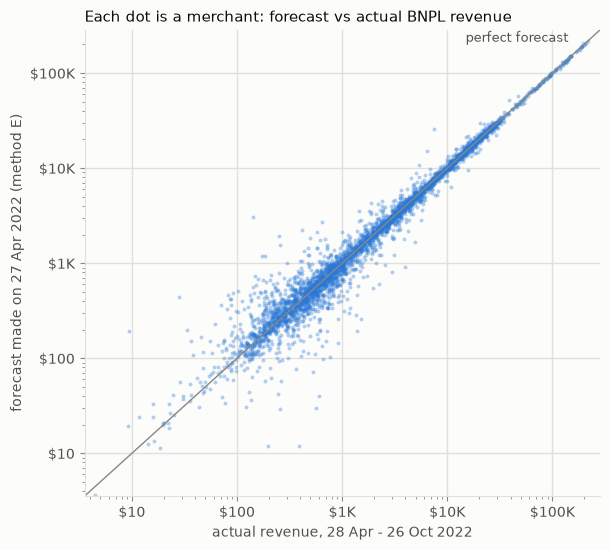

In [5]:
best = methods["E. share of the last 12 months"]
fig, ax = plt.subplots(figsize=(6.2, 5.6))
shown = (best > 0) & (target > 0)
ax.scatter(target[shown], best[shown], s=8, color=BLUE, alpha=0.35, linewidth=0)
limits = [target[shown].min() * 0.8, target.max() * 1.3]
ax.plot(limits, limits, color=MUTED, linewidth=1)
ax.text(limits[1] * 0.5, limits[1] * 0.75, "perfect forecast", color=INK_SECONDARY, fontsize=9, ha="right")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.xaxis.set_major_formatter(FuncFormatter(money))
ax.yaxis.set_major_formatter(FuncFormatter(money))
ax.set_xlabel("actual revenue, 28 Apr - 26 Oct 2022")
ax.set_ylabel("forecast made on 27 Apr 2022 (method E)")
ax.set_title("Each dot is a merchant: forecast vs actual BNPL revenue")
fig.tight_layout()
save(fig, "forecast_backtest")
plt.show()

Big merchants sit right on the line. The spread widens for small merchants, whose revenue in any six months depends
on a handful of orders. That uncertainty is unavoidable, so the forecast records how much data it's based on
(section 3).

## 2. Forecasting the fraud rate

A merchant's expected fraud rate is measured from 28 Aug 2021 onwards (`fraud.ipynb`). For a merchant with only a
few transactions, one big order can swing that rate. A common fix is to blend each merchant's rate with the average
for its category, weighting its own rate more the more transactions it has:

$$\text{fraud rate} = \frac{n}{n + k}\times\text{own rate} + \frac{k}{n + k}\times\text{category rate}$$

where $n$ is the merchant's number of transactions since 28 Aug 2021 and $k$ sets how much the category average
counts. To check whether blending helps, and to choose $k$, rates measured on the first half (28 Aug 2021 to
27 Feb 2022, from the fraud files) are used to predict the second half (28 Feb to 26 Oct 2022).

In [6]:
first_half, second_half = window(SECOND_SNAPSHOT, COVERAGE_END), window("2022-02-28", LAST_DAY)
category = features["category"]


def blended_rate(totals, k):
    own = (totals["expected_fraud"] / totals["sales"]).fillna(0)
    by_category = totals.groupby(category)[["expected_fraud", "sales"]].sum()
    category_rate = category.map(by_category["expected_fraud"] / by_category["sales"])
    weight = (totals["transactions"] / (totals["transactions"] + k)).fillna(0)  # no transactions: category rate
    return weight * own + (1 - weight) * category_rate


actual_rate = second_half["expected_fraud"] / second_half["sales"]
has_both = (first_half["sales"] > 0) & (second_half["sales"] > 0)
k_choices = [0, 5, 10, 20, 50, 100, 200, 500]
k_errors = pd.Series({
    k: np.average((blended_rate(first_half, k) - actual_rate)[has_both].abs(), weights=second_half["sales"][has_both])
    for k in k_choices
}, name="error in fraud rate, weighted by sales")
k_errors.index.name = "k (weight of the category average, in transactions)"
FRAUD_K = int(k_errors.idxmin())
display((100 * k_errors).round(3).to_frame("mean error (percentage points)").T)
print(f"k = {FRAUD_K} predicts the second half best")

"k (weight of the category average, in transactions)",0,5,10,20,50,100,200,500
mean error (percentage points),0.402,0.41,0.436,0.484,0.579,0.671,0.78,0.963


k = 0 predicts the second half best


The test gives a clear answer: **blending in the category average makes the forecast worse**, and each merchant's
own rate ($k=0$) predicts best. Fraud follows the size of each order, and order sizes vary a lot even within a
category. Antique shops, for example, have a median order of <span>\$125</span> but some orders worth tens of thousands. So a
merchant's own history says more than its category does.

The final fraud rate is therefore each merchant's own rate over the whole period since 28 Aug 2021. The category
rate is only used for the few merchants with no sales since then.

## 3. The final forecast

- **Sales:** sales in the last 12 months (27 Oct 2021 to 26 Oct 2022) x market growth. Growth is measured over the
  longest stretch with both years: 28 Feb to 26 Oct, 2022 vs 2021.
- **Merchants with less than a year of history** (first sale after 27 Oct 2021) have their sales scaled up to a full
  year. At least 90 days are assumed, so a merchant that just started isn't extrapolated from a few days.
- **Revenue** = forecast sales x take rate. **Fraud** = forecast sales x fraud rate.
- **Confidence** reflects how many transactions the forecast is based on. The backtest showed the spread for small
  merchants: under 100 transactions in the last 12 months is `low`, 100 to 999 is `medium`, 1,000 or more is `high`.
  Merchants with less than a year of history are always `low`.

In [7]:
MIN_HISTORY_DAYS = 90

last_year = window(LAST_12M_START, LAST_DAY)
growth = (window("2022-02-28", LAST_DAY)["sales"].sum() / window("2021-02-28", "2021-10-26")["sales"].sum())
history_days = features["history_days"].clip(upper=365)
annualise = 365 / history_days.clip(lower=MIN_HISTORY_DAYS)

forecast = pd.DataFrame(index=features.index)
forecast["limited_history"] = features["history_days"] < 365
forecast["forecast_sales_12m"] = last_year["sales"] * annualise * growth
forecast["forecast_revenue_12m"] = forecast["forecast_sales_12m"] * features["take_rate"] / 100
forecast["forecast_fraud_rate"] = blended_rate(window(SECOND_SNAPSHOT, LAST_DAY), FRAUD_K)
forecast["forecast_fraud_12m"] = forecast["forecast_sales_12m"] * forecast["forecast_fraud_rate"]
forecast["transactions_12m"] = last_year["transactions"]
forecast["confidence"] = np.select(
    [forecast["limited_history"] | (forecast["transactions_12m"] < 100), forecast["transactions_12m"] < 1000],
    ["low", "medium"], default="high")

assert forecast.notna().all().all(), "every merchant has a forecast"
forecast.reset_index().to_parquet(MERCHANT_FORECAST, index=False)
print(f"market growth: {growth - 1:+.1%}; forecast saved for {len(forecast):,} merchants to {MERCHANT_FORECAST}")

summary = forecast.groupby("confidence").agg(merchants=("forecast_sales_12m", "size"),
                                             forecast_revenue=("forecast_revenue_12m", "sum"))
summary["share_of_forecast_revenue"] = summary["forecast_revenue"] / summary["forecast_revenue"].sum()
display(summary.loc[["high", "medium", "low"]].style.format({"forecast_revenue": money, "share_of_forecast_revenue": "{:.1%}"}))

new = features.loc[forecast["limited_history"], ["merchant_name", "category", "first_transaction", "transactions"]]
new = new.join(forecast[["forecast_revenue_12m", "forecast_fraud_rate"]]).sort_values("forecast_revenue_12m", ascending=False)
print(f"{len(new)} merchants have less than a year of history:")
display(new.head(10).style.format({"forecast_revenue_12m": money, "forecast_fraud_rate": "{:.2%}",
                                   "first_transaction": "{:%d %b %Y}"}))

market growth: +20.2%; forecast saved for 4,026 merchants to curated/merchant_forecast.parquet


,merchants,forecast_revenue,share_of_forecast_revenue
confidence,,,
high,1144,$54.9M,74.8%
medium,1545,$14.9M,20.4%
low,1337,$3.6M,4.8%


22 merchants have less than a year of history:


,merchant_name,category,first_transaction,transactions,forecast_revenue_12m,forecast_fraud_rate
merchant_abn,,,,,,
14004773634,Dapibus Gravida Limited,"antique shops - sales, repairs, and restoration services",23 Nov 2021,5,$4K,34.31%
28311306642,Egestas Nunc Sed LLC,"antique shops - sales, repairs, and restoration services",08 Mar 2022,2,$4K,57.00%
89109402284,Interdum Feugiat Sed Incorporated,"antique shops - sales, repairs, and restoration services",16 Nov 2021,3,$4K,69.61%
10165489824,Nunc Sed Company,"jewelry, watch, clock, and silverware shops",30 Nov 2021,5,$3K,39.78%
76866488151,Euismod Urna Company,"antique shops - sales, repairs, and restoration services",10 Mar 2022,4,$3K,38.80%
64094501963,Dictum Mi Corporation,"antique shops - sales, repairs, and restoration services",06 Feb 2022,2,$3K,64.67%
42461534060,Elit LLP,"antique shops - sales, repairs, and restoration services",26 Nov 2021,2,$3K,57.37%
94009500943,Dapibus Corp.,"antique shops - sales, repairs, and restoration services",26 Nov 2021,6,$2K,37.64%
18261886835,Massa Rutrum LLP,"antique shops - sales, repairs, and restoration services",23 Jan 2022,2,$2K,36.54%


In [8]:
low_share = summary.loc["low", "share_of_forecast_revenue"]
show_markdown(f"""
### Summary

- **Method.** Five forecast methods were tested by forecasting 28 Apr to 26 Oct 2022 from the data before it. The best
  (error {backtest.loc['E. share of the last 12 months', 'error, $-weighted (WAPE)']:.1%}, rank correlation
  {backtest.loc['E. share of the last 12 months', 'rank correlation (Spearman)']:.3f}, finding
  {backtest.loc['E. share of the last 12 months', 'actual top 100 found']:.0f} of the actual top 100) is the simplest:
  a merchant's last 12 months, grown at the market rate (**{growth - 1:+.1%}**). Applying a merchant's own growth
  rate made forecasts worse.
- **Fraud rate.** Each merchant's own expected fraud rate since 28 Aug 2021. Blending it with the category average
  was tested and made predictions of the most recent eight months worse (best weight: k = {FRAUD_K}).
- **Uncertainty.** Merchants with low confidence (fewer than 100 transactions in the last year, or less than a year
  of history) are **{summary.loc['low', 'merchants']:,}** of {len(forecast):,}, but only **{low_share:.1%}** of
  forecast revenue. **{len(new)}** merchants have traded for less than a year.

**Output:** `{MERCHANT_FORECAST}`, used by `ranking.ipynb`.
""")


### Summary

- **Method.** Five forecast methods were tested by forecasting 28 Apr to 26 Oct 2022 from the data before it. The best
  (error 5.0%, rank correlation
  0.977, finding
  98 of the actual top 100) is the simplest:
  a merchant's last 12 months, grown at the market rate (**+20.2%**). Applying a merchant's own growth
  rate made forecasts worse.
- **Fraud rate.** Each merchant's own expected fraud rate since 28 Aug 2021. Blending it with the category average
  was tested and made predictions of the most recent eight months worse (best weight: k = 0).
- **Uncertainty.** Merchants with low confidence (fewer than 100 transactions in the last year, or less than a year
  of history) are **1,337** of 4,026, but only **4.8%** of
  forecast revenue. **22** merchants have traded for less than a year.

**Output:** `curated/merchant_forecast.parquet`, used by `ranking.ipynb`.
